# Hybrid Search in RAG Applications

## 1. What is Hybrid Search?

**Hybrid Search** in a Retrieval-Augmented Generation (RAG) application is a retrieval strategy that **combines semantic (vector) search and keyword (lexical) search** to fetch the most relevant documents before sending them to a Large Language Model (LLM).

Instead of relying on a single retrieval method, hybrid search leverages:
- **Meaning-based understanding** (semantic similarity)
- **Exact term matching** (keywords, IDs, error codes)

This approach significantly improves accuracy, recall, and reliability in real-world RAG systems.

---

## 2. Why Hybrid Search is Needed in RAG

RAG systems fail most often during **retrieval**, not generation. Hybrid search reduces retrieval blind spots.

### Problems with Only Vector Search
Vector search may miss:
- Exact error codes (e.g., ORA-00942)
- Report names (AMS_8.3, OLFM)
- IDs, dates, ticket numbers
- Column or table names

Example: Query: ORA-00942 error in AMS 8.3 report

Vector search may retrieve:
> "Database permission issue"

But miss the **exact Oracle error documentation**.

---

### Problems with Only Keyword Search
Keyword search may miss:
- Synonyms
- Paraphrased questions
- Conceptual meaning

Example: Query: Why is my report balance incorrect?

Keyword search may fail to match:
> "Mismatch due to late-arriving transactions"

---

## 3. Hybrid Search = Best of Both Worlds

Hybrid search ensures:
- High **recall** (nothing important missed)
- High **precision** (most relevant docs ranked first)

### Conceptual Flow

User Query
│
├──► Semantic Search (Vector DB)
│
├──► Keyword Search (BM25 / Text Index)
│
▼
Merge + Rank Results
│
▼
Top Documents
│
▼
LLM → Final Answer



---

## 4. Core Components of Hybrid Search

### 4.1 Semantic (Vector) Search
- Uses embeddings
- Finds meaning and context
- Handles paraphrases and synonyms

Examples:
- ChromaDB
- FAISS
- Pinecone
- Weaviate

---

### 4.2 Keyword (Lexical) Search
- Uses exact word matching
- Great for structured terms

Examples:
- BM25
- Elasticsearch
- OpenSearch
- SQL Full-Text Search

---

## 5. How Hybrid Results Are Combined

### 5.1 Union-Based Merge (Recall First)
- Take top N vector results
- Take top M keyword results
- Combine all documents

Best when **missing a document is costly**

---

### 5.2 Weighted Score Fusion (Most Common)

Each document receives a combined score:

final_score =
(α × vector_similarity)

(β × keyword_score)



Example:
- Vector similarity: 0.82
- Keyword relevance: 0.65
- Final score determines ranking

---

### 5.3 Reranking (Best Quality)
1. Retrieve many documents
2. Use a reranker model or LLM
3. Reorder by contextual relevance
4. Send top K docs to LLM

This is the **production-grade approach**.

---

## 6. Example: Hybrid Search in a RAG Application

### User Question
Why is customer balance mismatching in OLFM report?


### Vector Search Retrieves
- Currency conversion issues
- Timing differences in ledger postings

### Keyword Search Retrieves
- OLFM
- customer balance
- mismatch

### Hybrid Result
- Business explanation
- Report-specific logic
- Known documented issues

The LLM now has **accurate + complete context**.

---

## 7. When Should You Use Hybrid Search?

Hybrid search is recommended when your data includes:

- Report names
- Error codes
- SQL column names
- Log messages
- Business + technical terminology
- Enterprise documentation

👉 **Enterprise RAG systems should use hybrid search by default.**

---

## 8. Hybrid Search in Enterprise RAG Use Cases

Perfect for:
- Report issue analyzers
- Metadata-driven validation systems
- SQL and database troubleshooting
- Compliance and audit reports
- Customer support knowledge bases

---

## 9. One-Line Summary

> **Hybrid search in RAG combines semantic understanding with exact keyword matching to retrieve more accurate, complete, and reliable context for LLM responses.**

---

## 10. Next Enhancements (Optional)

- BM25 + Vector Fusion
- LangChain Hybrid Retriever
- Reranker Integration
- Metadata-aware Hybrid Search
- Query Expansion + Hybrid Retrieval

---






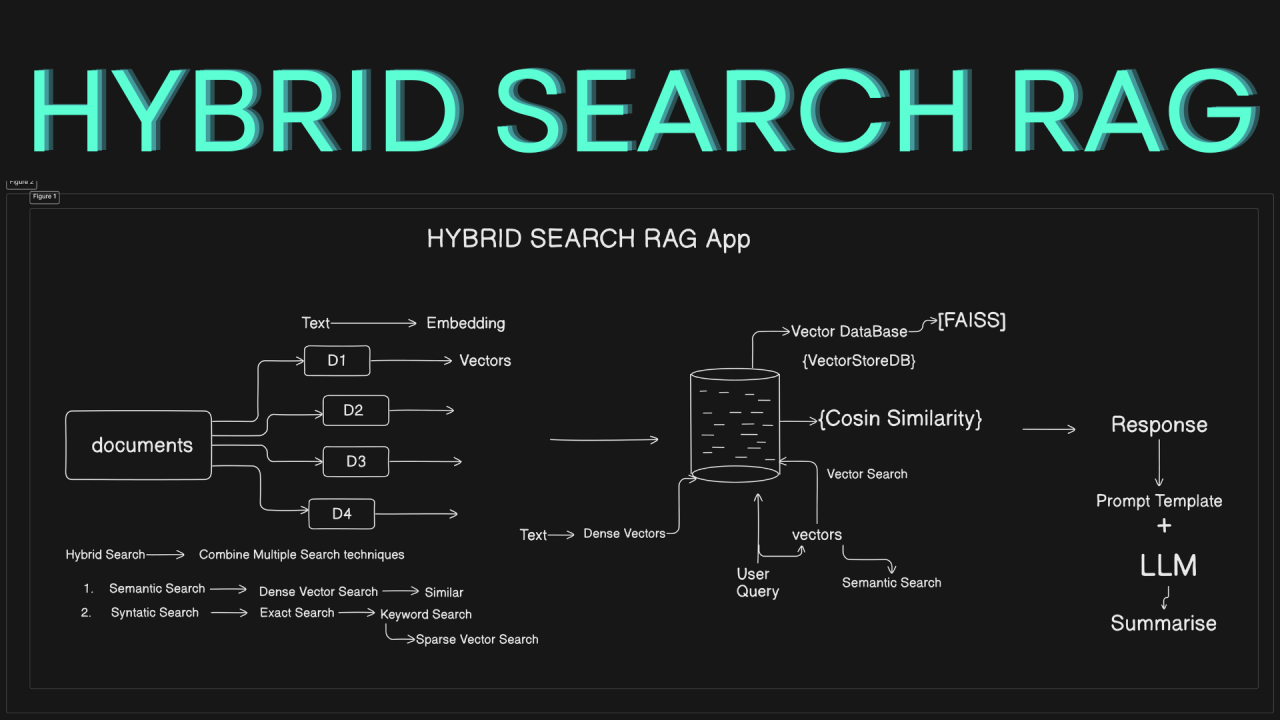

https://www.linkedin.com/pulse/hybrid-search-rag-new-frontier-information-retrieval-atul-kumar-vnd5c/

In the rapidly evolving landscape of information retrieval, Hybrid Search is gaining traction, particularly in the domain of Retrieval-Augmented Generation (RAG) applications. As organizations increasingly rely on large language models (LLMs) to provide accurate, contextually relevant answers, the role of efficient and effective search techniques becomes paramount. The diagram above illustrates the architecture of a Hybrid Search RAG App, combining the strengths of both semantic and syntactic search methods to optimize the retrieval process.

### Understanding Hybrid Search
Hybrid Search leverages multiple search techniques to retrieve the most relevant information from a vast pool of documents. The key idea is to combine the advantages of Semantic Search and Syntactic Search:

Semantic Search: This approach focuses on understanding the meaning behind the query. It converts text into dense vectors (embeddings) that capture semantic information, enabling the system to identify documents that are similar in meaning, even if they don't contain the exact query terms. This is particularly useful in scenarios where the user query may be phrased differently from the content in the documents.
Syntactic Search: This method relies on exact matches of keywords and phrases. It performs a traditional search, often enhanced with techniques like sparse vector search, to find documents that contain specific terms. This approach is beneficial when the exact wording is crucial, or when searching for specific facts.

### How the Hybrid Search RAG App Works
The diagram outlines a robust pipeline for Hybrid Search in an RAG application:

* Document Processing: 
The system begins by processing a collection of documents (D1, D2, D3, D4). Each document is transformed into embeddings, which are dense vectors representing the semantic content of the text.

* Vector Storage: 
These vectors are stored in a vector database, such as FAISS (Facebook AI Similarity Search), within a VectorStoreDB. This storage system allows for efficient vector search using techniques like cosine similarity to measure the closeness of vectors.

* User Query Handling: 
When a user submits a query, the system converts the text into dense vectors. The Hybrid Search mechanism kicks in, combining semantic search (vector-based) with syntactic search (keyword-based) to retrieve the most relevant documents from the database.

* Cosine Similarity and Vector Search: 
The system uses cosine similarity to compare the query vectors with document vectors in the database. This approach ensures that the most semantically similar documents are retrieved, even if they don't contain exact keyword matches.

* Response Generation: 
The retrieved documents are then passed to the LLM, which uses a prompt template to generate a response. This response can be further summarized to provide a concise and accurate answer to the user's query.


### Why Hybrid Search Matters
The integration of both semantic and syntactic search methods in a single system addresses the limitations of each approach when used independently. Semantic Search is excellent for understanding context and meaning, but it may overlook exact matches that are crucial in certain scenarios. Conversely, Syntactic Search can miss the forest for the trees, focusing too narrowly on specific terms without grasping the broader meaning. By combining these methods, Hybrid Search provides a more balanced and comprehensive retrieval process.

# Conclusion
As the demand for accurate and context-aware information retrieval grows, Hybrid Search represents a significant advancement in the field. The ability to leverage both semantic and syntactic search techniques in an RAG application enhances the quality of responses generated by LLMs, making them more reliable and relevant. This approach not only improves user satisfaction but also sets the stage for more sophisticated and nuanced information retrieval systems in the future.

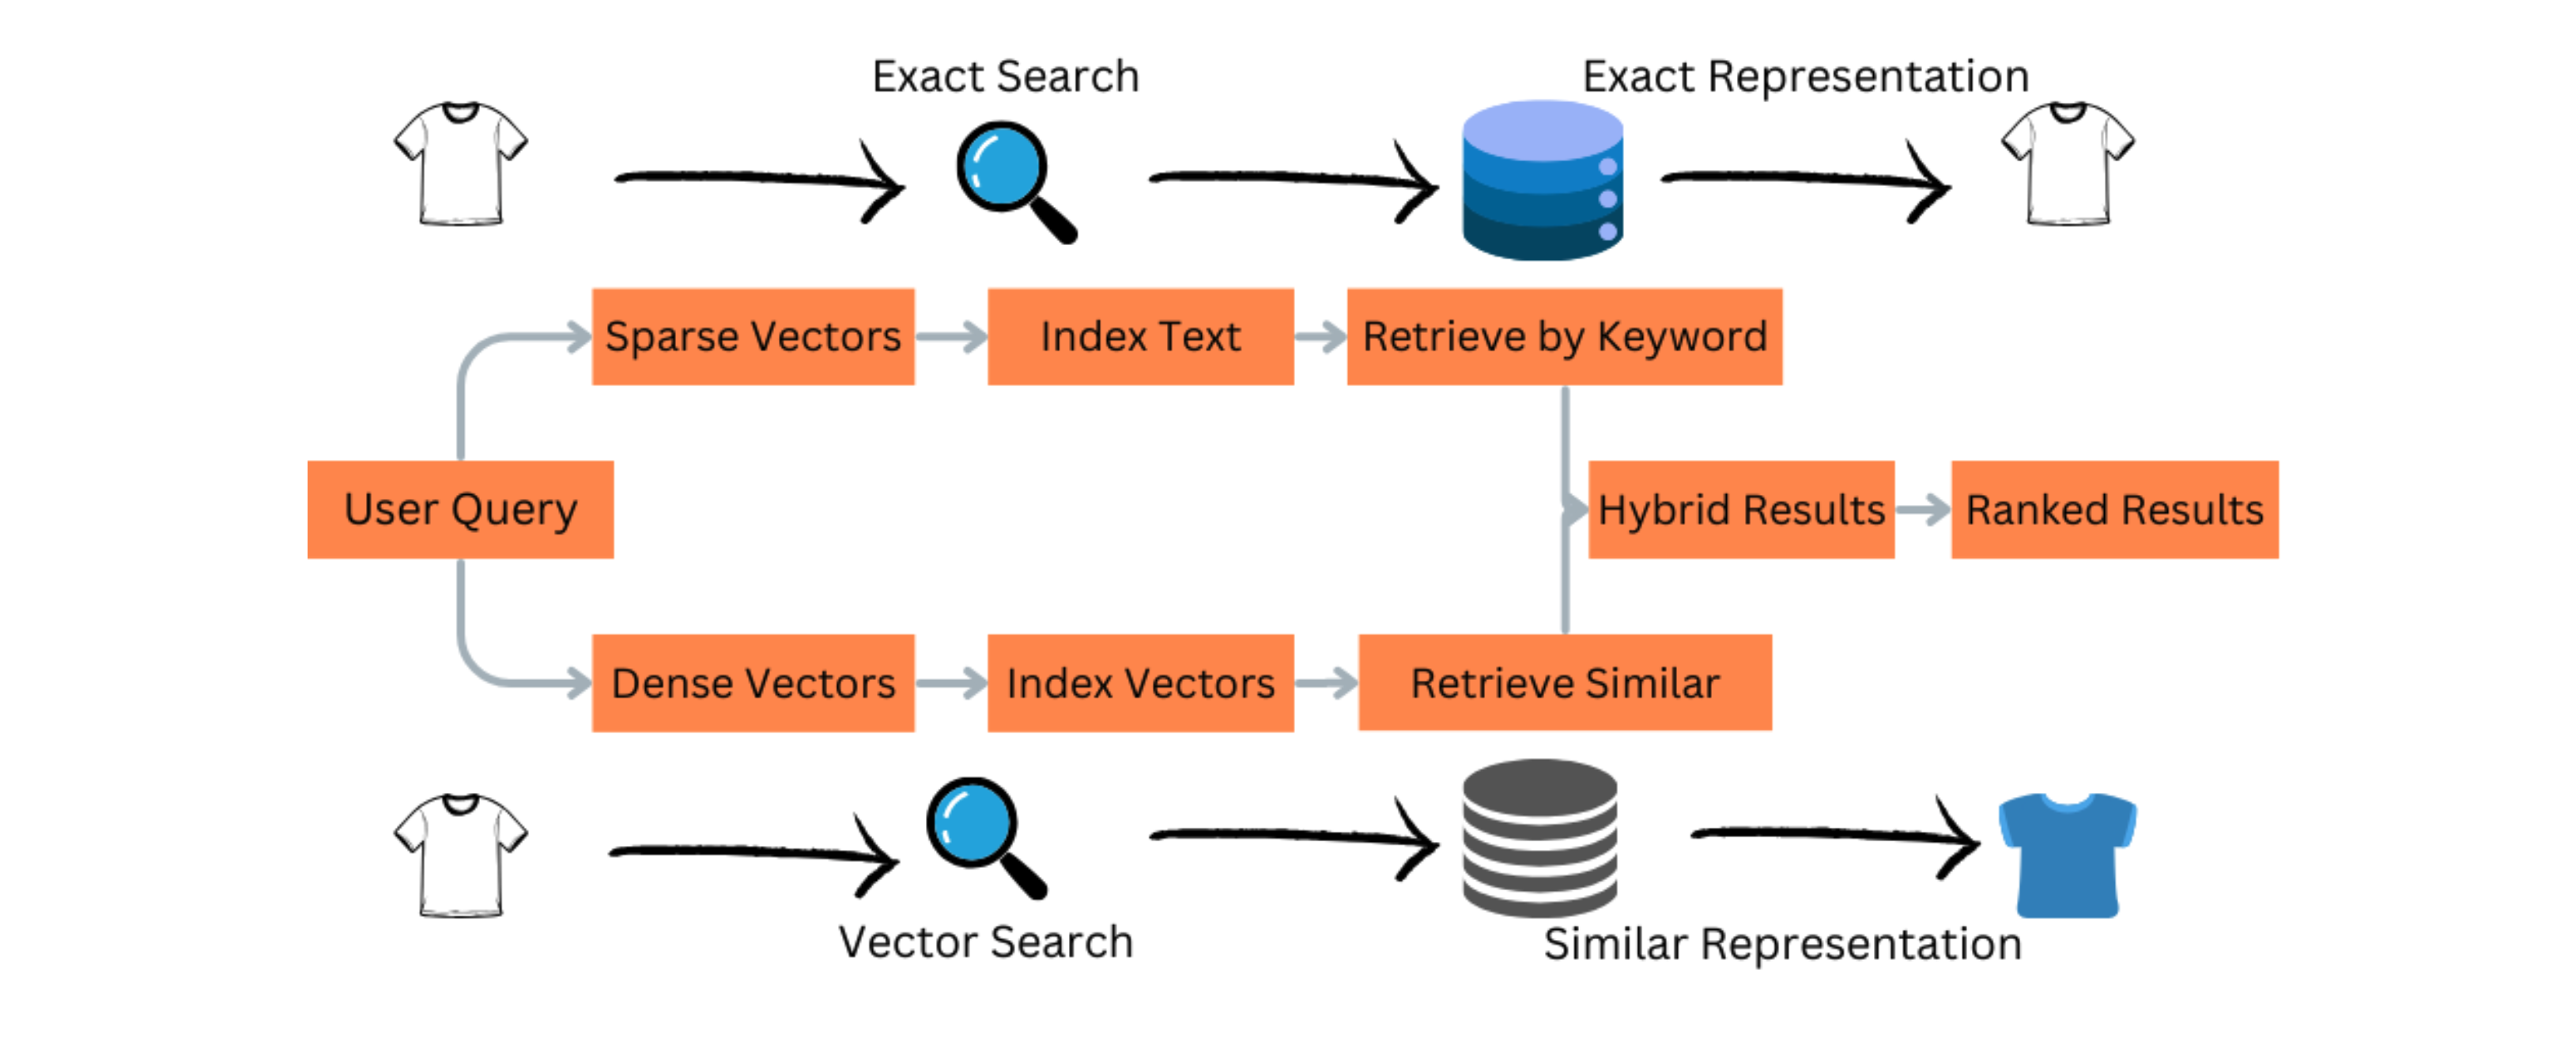